In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

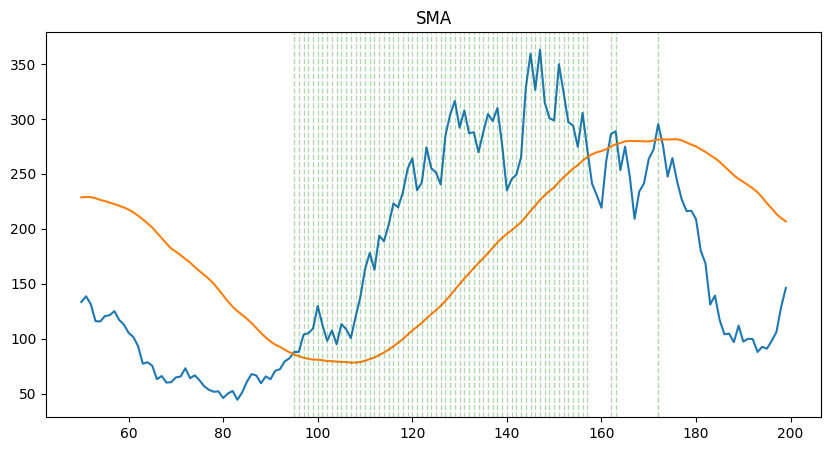

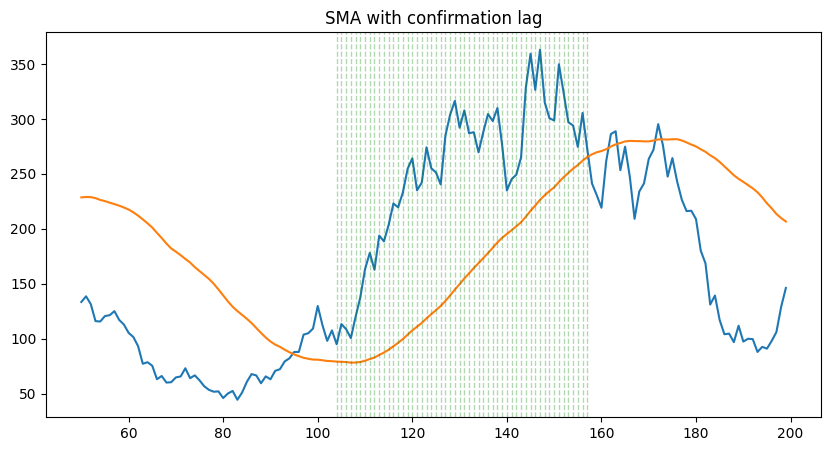

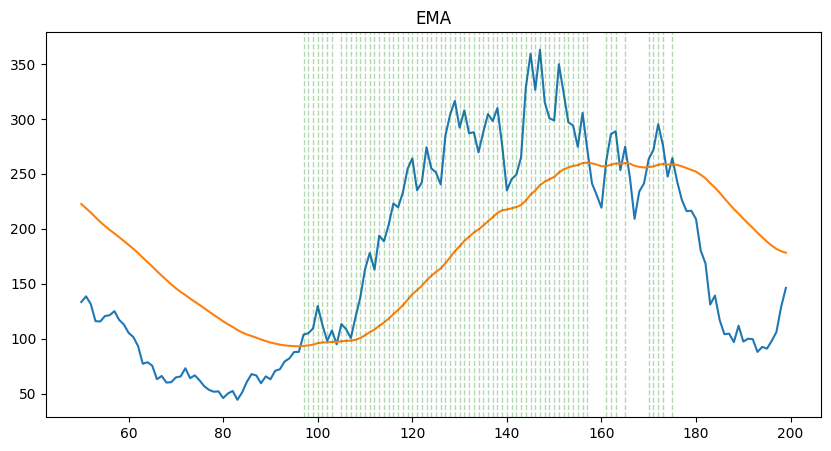

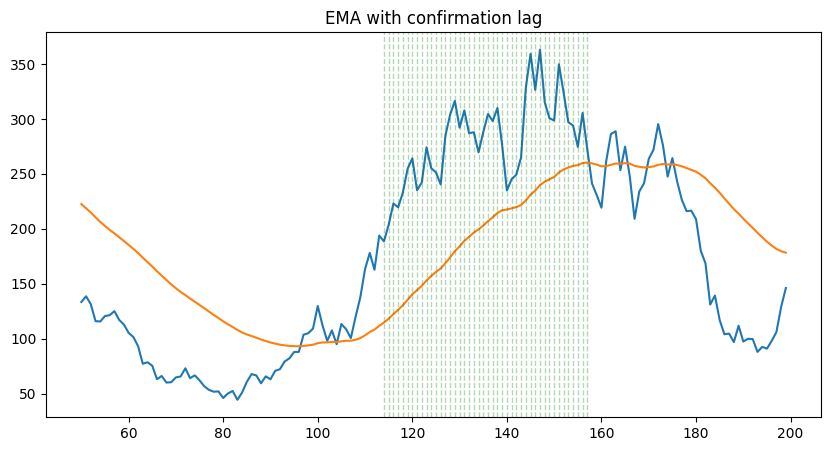

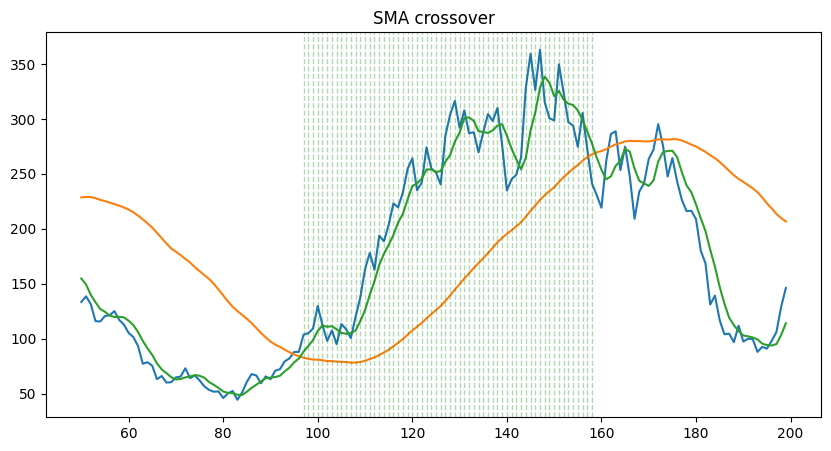

In [10]:
np.random.seed(0)
n = 200
returns = np.random.normal(0, .1, size=n)
returns_cumul = (1+returns).cumprod()-1
prices = 100*(returns_cumul+1)
prices[0] = 100


df = pd.DataFrame()
df['price'] = prices

# SMA
window_lt = 50
df['SMA_lt'] = df['price'].rolling(window_lt).mean()
df['is_bullish_1'] = df['price']>df['SMA_lt']
plt.figure(figsize=(10,5))
plt.plot(df['price'].iloc[window_lt:])
plt.plot(df['SMA_lt'].iloc[window_lt:])
for i in range(window_lt, df.shape[0]):
    if df['is_bullish_1'].iloc[i]==True:
        plt.axvline(x=i, color='green', alpha=0.3, linestyle='--', linewidth=1)
plt.title('SMA')

# SMA with confirmation lag
window_lt = 50
lag = 10
df['SMA_lt'] = df['price'].rolling(window_lt).mean()
df['diff'] = df['price']-df['SMA_lt']
df['diff_min'] = df['diff'].rolling(window=lag).min()
df['is_bullish_2'] = df['diff_min']>0
plt.figure(figsize=(10,5))
plt.plot(df['price'].iloc[window_lt:])
plt.plot(df['SMA_lt'].iloc[window_lt:])
for i in range(window_lt, df.shape[0]):
    if df['is_bullish_2'].iloc[i]==True:
        plt.axvline(x=i, color='green', alpha=0.3, linestyle='--', linewidth=1)
plt.title('SMA with confirmation lag')

# EMA
window_lt = 50
df['EMA_lt'] = df['price'].ewm(span=window_lt, min_periods=window_lt).mean()
df['is_bullish_3'] = df['price']>df['EMA_lt']
plt.figure(figsize=(10,5))
plt.plot(df['price'].iloc[window_lt:])
plt.plot(df['EMA_lt'].iloc[window_lt:])
for i in range(window_lt, df.shape[0]):
    if df['is_bullish_3'].iloc[i]==True:
        plt.axvline(x=i, color='green', alpha=0.3, linestyle='--', linewidth=1)
plt.title('EMA')

# EMA with confirmation lag
window_lt = 50
lag = 10
df['EMA_lt'] = df['price'].ewm(span=window_lt, min_periods=window_lt).mean()
df['diff'] = df['price']-df['EMA_lt']
df['diff_min'] = df['diff'].rolling(window=lag).min()
df['is_bullish_4'] = df['diff_min']>0
plt.figure(figsize=(10,5))
plt.plot(df['price'].iloc[window_lt:])
plt.plot(df['EMA_lt'].iloc[window_lt:])
for i in range(window_lt, df.shape[0]):
    if df['is_bullish_4'].iloc[i]==True:
        plt.axvline(x=i, color='green', alpha=0.3, linestyle='--', linewidth=1)
plt.title('EMA with confirmation lag')

# SMA crossover
window_lt = 50
window_st = 5
df['SMA_lt'] = df['price'].rolling(window_lt).mean()
df['SMA_st'] = df['price'].rolling(window_st).mean()
df['is_bullish_5'] = df['SMA_st']>df['SMA_lt']
plt.figure(figsize=(10,5))
plt.plot(df['price'].iloc[window_lt:])
plt.plot(df['SMA_lt'].iloc[window_lt:])
plt.plot(df['SMA_st'].iloc[window_lt:])
for i in range(window_lt, df.shape[0]):
    if df['is_bullish_5'].iloc[i]==True:
        plt.axvline(x=i, color='green', alpha=0.3, linestyle='--', linewidth=1)
plt.title('SMA crossover')
print()



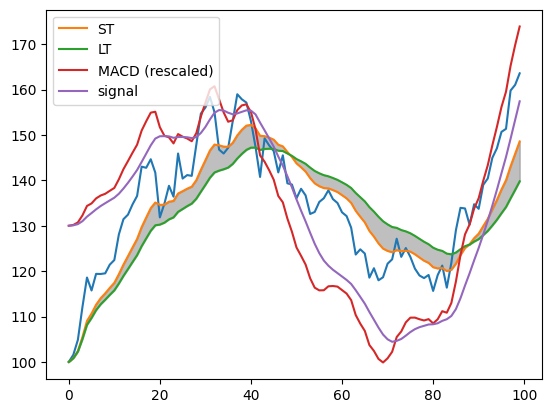

In [74]:
np.random.seed(0)

returns = np.random.normal(.05/12, .1/np.sqrt(12), size=100)
returns[0] = 0
prices = 100*(1+returns).cumprod()

plt.plot(prices)
ewm_ST = pd.DataFrame(prices).ewm(span=12).mean()
ewm_LT = pd.DataFrame(prices).ewm(span=26).mean()
plt.plot(ewm_ST, label='ST')
plt.plot(ewm_LT, label='LT')
plt.fill_between(ewm_ST.index, ewm_ST.values.flatten(), ewm_LT.values.flatten(), color='gray', alpha=0.5)

MACD = ewm_ST - ewm_LT
signal = pd.DataFrame(MACD).ewm(span=9).mean()

plt.plot(MACD*5+130, label='MACD (rescaled)')
plt.plot(signal*5+130, label='signal')
plt.legend()
plt.show()

# plt.figure()
# plt.plot(MACD, color='r', label='MACD')
# plt.hlines(y=0, xmin=0, xmax=100)
# plt.show()